In [ ]:
!pip install lime

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Oversampling
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import ExtraTreesClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import PartialDependenceDisplay

In [ ]:
df = pd.read_csv("/content/diabetes_binary_health_indicators_BRFSS2015 (1).csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Select Final Features

In [ ]:
selected_features = [
    'GenHlth',
    'HighBP',
    'BMI',
    'DiffWalk',
    'HighChol',
    'Age',
    'HeartDiseaseorAttack',
    'PhysHlth',
    'MentHlth',
    'Income'
]

X = df[selected_features]

y = df["Diabetes_binary"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X,y, test_size=0.2, random_state=42, stratify=y)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (202944, 10)
Testing Shape: (50736, 10)


In [ ]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Handle Imbalance (Random Oversampling)

In [ ]:
ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train_scaled,
    y_train
)

print("Before Oversampling:")
print(y_train.value_counts())

print("\nAfter Oversampling:")
print(pd.Series(y_train_resampled).value_counts())

Before Oversampling:
Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64

After Oversampling:
Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64


Extra Trees **Model**

In [ ]:
et_model = ExtraTreesClassifier(
    random_state=42
)

et_model.fit(X_train_resampled, y_train_resampled)

ExtraTreesClassifier(random_state=42)

Hyperparameter Tuning

In [ ]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, None],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

grid_search = GridSearchCV(
    estimator=ExtraTreesClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
#Train Final Model
best_et_model = grid_search.best_estimator_

best_et_model.fit(X_train_resampled, y_train_resampled)

y_pred = best_et_model.predict(X_test_scaled)
y_prob = best_et_model.predict_proba(X_test_scaled)[:, 1]

Evaluation **Metrics**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("AUC:", auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8002995900346894
AUC: 0.7074835825473388

Classification Report:

              precision    recall  f1-score   support

         0.0       0.89      0.88      0.88     43667
         1.0       0.30      0.32      0.31      7069

    accuracy                           0.80     50736
   macro avg       0.59      0.60      0.60     50736
weighted avg       0.81      0.80      0.80     50736



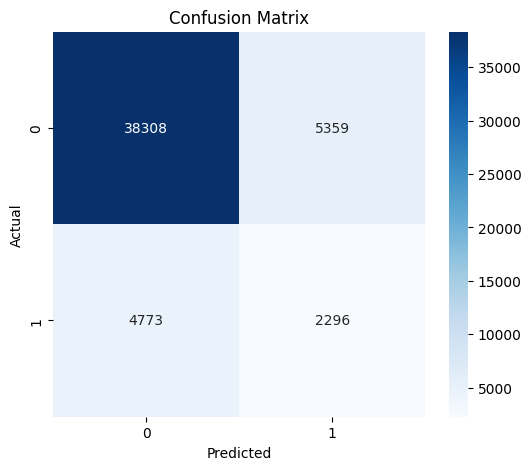

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

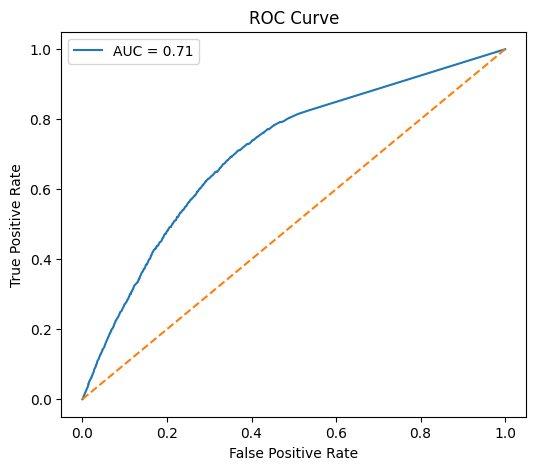

In [ ]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# explainability technique

# Feature Importance

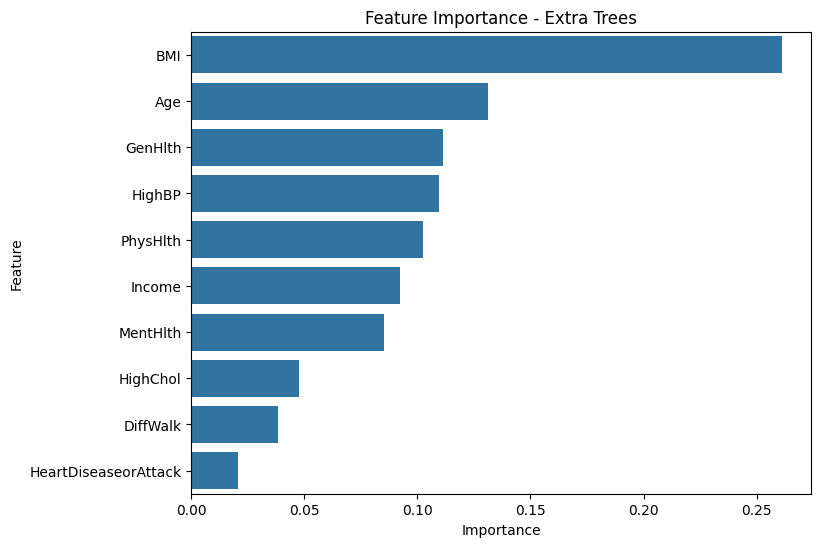

In [ ]:
importance = best_et_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Extra Trees")

plt.show()

# SHAP Explainer

In [ ]:
X_shap_df = pd.DataFrame(
    X_test_scaled[:20],
    columns=selected_features
)

In [ ]:
X_shap = X_test_scaled[:20]

explainer = shap.Explainer(
    best_et_model.predict,
    X_shap,
    algorithm="permutation"
)

shap_values = explainer(X_shap)

PermutationExplainer explainer: 21it [00:13,  1.90s/it]


/tmp/ipykernel_18780/1406936018.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


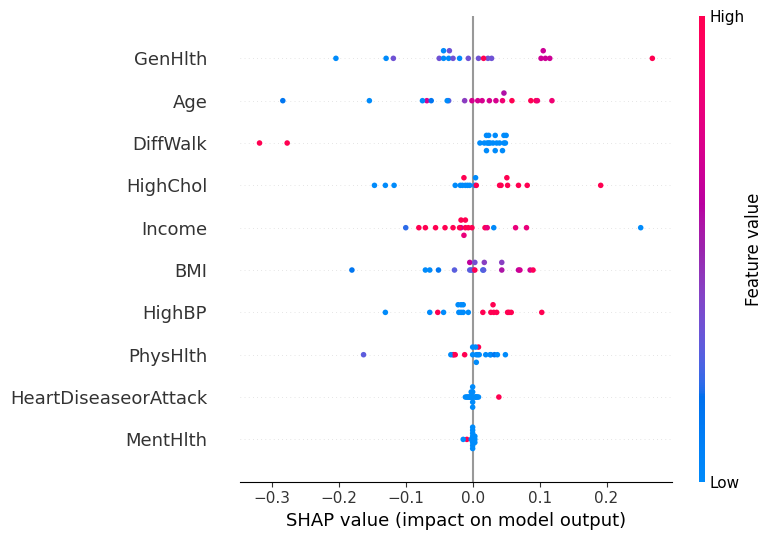

In [ ]:
shap.summary_plot(
    shap_values.values,
    X_test.iloc[:20],
    feature_names=selected_features
)

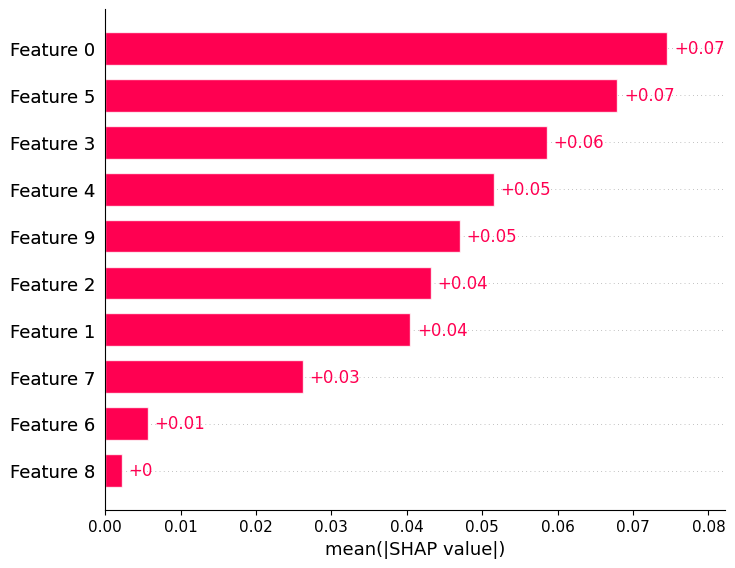

In [ ]:
#SHAP Bar Plot
shap.plots.bar(shap_values)

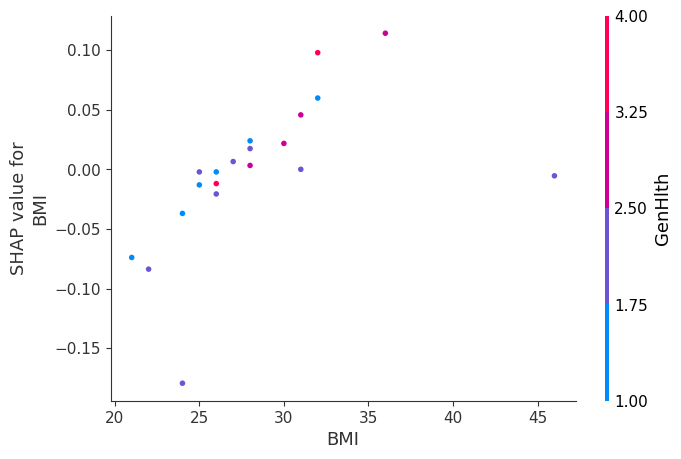

In [ ]:
#SHAP Dependence Plot
shap.dependence_plot(
    "BMI",
    shap_values.values,
    X_test.iloc[:20],
    feature_names=selected_features
)

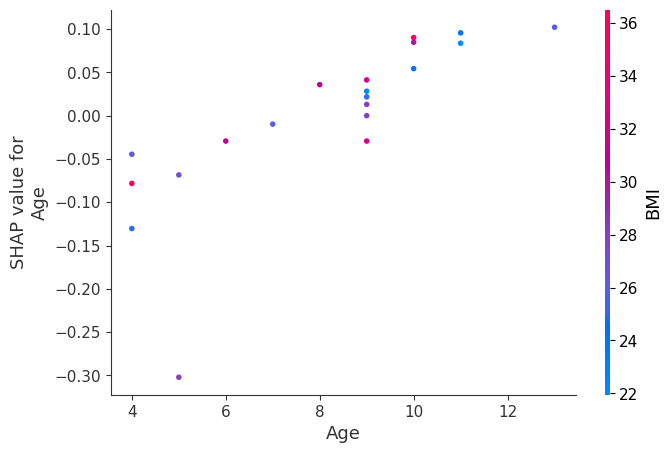

In [ ]:
shap.dependence_plot(
    "Age",
    shap_values.values,
    X_test.iloc[:20],
    feature_names=selected_features
)

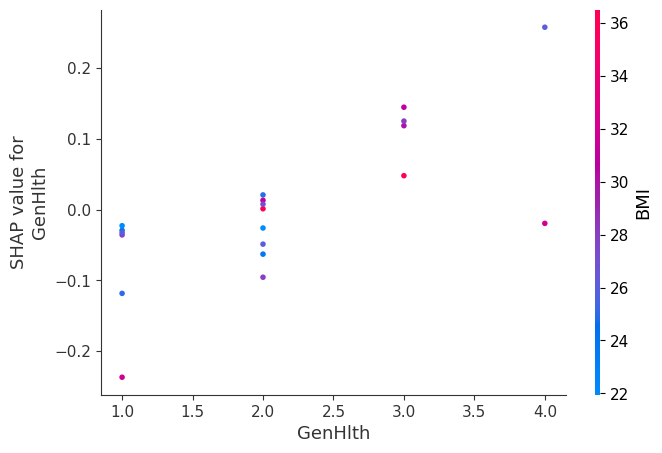

In [ ]:
shap.dependence_plot(
    "GenHlth",
    shap_values.values,
    X_test.iloc[:20],
    feature_names=selected_features
)

# PDP **Plot**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning

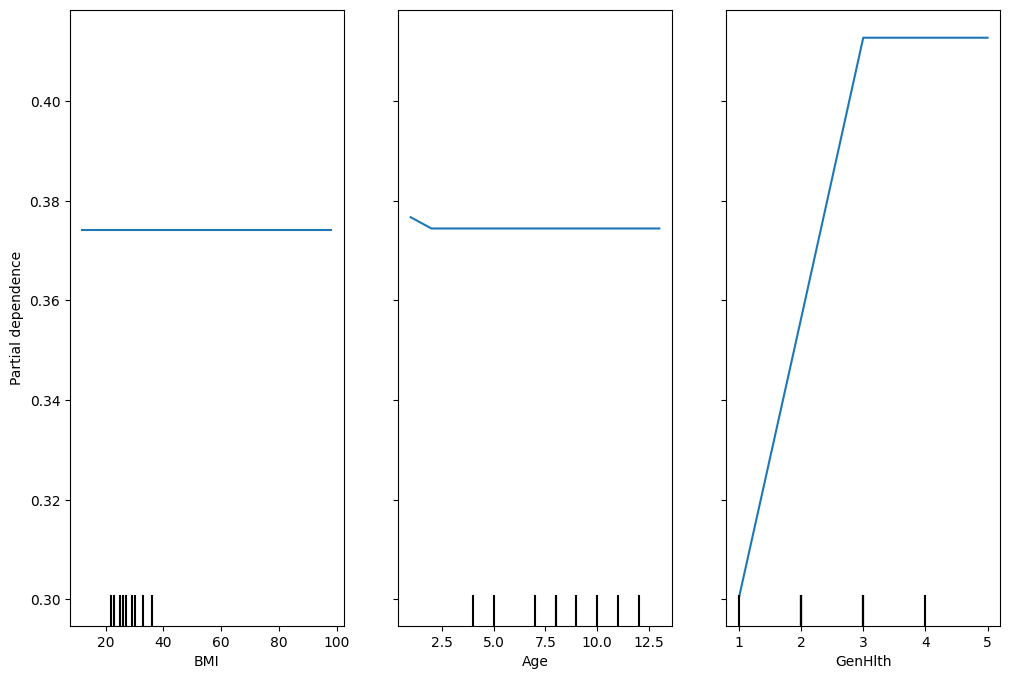

In [ ]:
features_to_plot = ['BMI', 'Age', 'GenHlth']

fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    best_et_model,
    X_test,
    features_to_plot,
    ax=ax
)

plt.show()

The PDP plots indicate that the Extra Trees model relies more on complex feature interactions rather than simple linear relationships for some variables such as BMI and Age.

# LIME Explainer

In [ ]:
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train_resampled),
    feature_names=selected_features,
    class_names=['Non-Diabetic', 'Diabetic'],
    mode='classification'
)

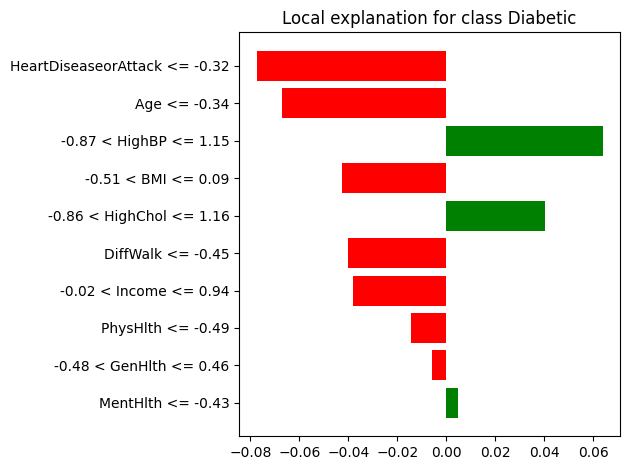

In [ ]:
#Explain Single Prediction with LIME
exp = explainer_lime.explain_instance(
    X_test_scaled[0],
    best_et_model.predict_proba,
    num_features=10
)

fig = exp.as_pyplot_figure()

plt.tight_layout()

plt.show()

LIME explanations demonstrate that the model decision varies across individuals, highlighting the personalized nature of diabetes risk prediction.